# Seattle Airbnb Analysis (CRISP-DM Approach)

## Step 1: Business Understanding

This project explores the Seattle Airbnb dataset to derive actionable insights and answer key business questions:

1. What is the price distribution across neighborhoods?
2. How do room types influence price?
3. Are certain host behaviors or amenities associated with higher prices?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
%matplotlib inline


In [2]:
def load_and_clean_data(filepath):
    '''
    Loads Airbnb dataset from CSV, cleans the price column.

    Parameters:
        filepath (str): Path to CSV file.

    Returns:
        DataFrame: Cleaned dataframe with price column as float.
    '''
    df = pd.read_csv(filepath)
    df['price'] = df['price'].replace({r'\$': '', r',': ''}, regex=True).astype(float)
    return df

# Load the data
df = load_and_clean_data('listings.csv')
print("Shape:", df.shape)
df.head()


Shape: (3818, 92)


,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,review_scores_value,requires_license,license,jurisdiction_names,instant_bookable,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month
0,241032,https://www.airbnb.com/rooms/241032,20160104002432,2016-01-04,Stylish Queen Anne Apartment,NaN,Make your self at home in this charming one-be...,Make your self at home in this charming one-be...,none,NaN,...,10.0,f,NaN,WASHINGTON,f,moderate,f,f,2,4.07
1,953595,https://www.airbnb.com/rooms/953595,20160104002432,2016-01-04,Bright & Airy Queen Anne Apartment,Chemically sensitive? We've removed the irrita...,"Beautiful, hypoallergenic apartment in an extr...",Chemically sensitive? We've removed the irrita...,none,"Queen Anne is a wonderful, truly functional vi...",...,10.0,f,NaN,WASHINGTON,f,strict,t,t,6,1.48
2,3308979,https://www.airbnb.com/rooms/3308979,20160104002432,2016-01-04,New Modern House-Amazing water view,New modern house built in 2013. Spectacular s...,"Our house is modern, light and fresh with a wa...",New modern house built in 2013. Spectacular s...,none,Upper Queen Anne is a charming neighborhood fu...,...,10.0,f,NaN,WASHINGTON,f,strict,f,f,2,1.15
3,7421966,https://www.airbnb.com/rooms/7421966,20160104002432,2016-01-04,Queen Anne Chateau,A charming apartment that sits atop Queen Anne...,NaN,A charming apartment that sits atop Queen Anne...,none,NaN,...,NaN,f,NaN,WASHINGTON,f,flexible,f,f,1,NaN
4,278830,https://www.airbnb.com/rooms/278830,20160104002432,2016-01-04,Charming craftsman 3 bdm house,Cozy family craftman house in beautiful neighb...,Cozy family craftman house in beautiful neighb...,Cozy family craftman house in beautiful neighb...,none,We are in the beautiful neighborhood of Queen ...,...,9.0,f,NaN,WASHINGTON,f,strict,f,f,1,0.89


## Step 3: Data Cleaning

### Why Clean?
Cleaning ensures that our insights are based on reliable data. We:
- Remove irrelevant columns
- Handle missing values
- Convert formats for analysis

### Handling Missing Data
- `bathrooms`, `bedrooms`, `beds`: filled with median — these are important for pricing, and median avoids skew.
- `host_response_time`, `property_type`, `room_type`, `bed_type`: filled with 'Unknown' — categorical fields that can't be imputed numerically.
- `square_feet`, `weekly_price`, `monthly_price`: dropped due to too many nulls and not essential for core questions.


# CRISP-DM Process

### 1. Business Understanding
The goal of this project is to analyze Airbnb listings in Seattle to answer key business questions such as:

1. How do average listing prices vary across neighborhoods?
2. What features are most correlated with price?
3. Are there seasonal or behavioral trends in listings?

### 2. Data Understanding
We begin by importing and exploring the dataset to understand its structure and the kind of data we are working with.

In [6]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set(style="whitegrid")
%matplotlib inline

# Load the Airbnb dataset
df = pd.read_csv('listings.csv')

# View the shape and column names
print("Shape:", df.shape)
df.head()

Shape: (3818, 92)


,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,review_scores_value,requires_license,license,jurisdiction_names,instant_bookable,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month
0,241032,https://www.airbnb.com/rooms/241032,20160104002432,2016-01-04,Stylish Queen Anne Apartment,NaN,Make your self at home in this charming one-be...,Make your self at home in this charming one-be...,none,NaN,...,10.0,f,NaN,WASHINGTON,f,moderate,f,f,2,4.07
1,953595,https://www.airbnb.com/rooms/953595,20160104002432,2016-01-04,Bright & Airy Queen Anne Apartment,Chemically sensitive? We've removed the irrita...,"Beautiful, hypoallergenic apartment in an extr...",Chemically sensitive? We've removed the irrita...,none,"Queen Anne is a wonderful, truly functional vi...",...,10.0,f,NaN,WASHINGTON,f,strict,t,t,6,1.48
2,3308979,https://www.airbnb.com/rooms/3308979,20160104002432,2016-01-04,New Modern House-Amazing water view,New modern house built in 2013. Spectacular s...,"Our house is modern, light and fresh with a wa...",New modern house built in 2013. Spectacular s...,none,Upper Queen Anne is a charming neighborhood fu...,...,10.0,f,NaN,WASHINGTON,f,strict,f,f,2,1.15
3,7421966,https://www.airbnb.com/rooms/7421966,20160104002432,2016-01-04,Queen Anne Chateau,A charming apartment that sits atop Queen Anne...,NaN,A charming apartment that sits atop Queen Anne...,none,NaN,...,NaN,f,NaN,WASHINGTON,f,flexible,f,f,1,NaN
4,278830,https://www.airbnb.com/rooms/278830,20160104002432,2016-01-04,Charming craftsman 3 bdm house,Cozy family craftman house in beautiful neighb...,Cozy family craftman house in beautiful neighb...,Cozy family craftman house in beautiful neighb...,none,We are in the beautiful neighborhood of Queen ...,...,9.0,f,NaN,WASHINGTON,f,strict,f,f,1,0.89


In [7]:
# Overview of data types and missing values
df.info()

# Check for null values
df.isnull().sum().sort_values(ascending=False)

# Descriptive statistics
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3818 entries, 0 to 3817
Data columns (total 92 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                3818 non-null   int64  
 1   listing_url                       3818 non-null   object 
 2   scrape_id                         3818 non-null   int64  
 3   last_scraped                      3818 non-null   object 
 4   name                              3818 non-null   object 
 5   summary                           3641 non-null   object 
 6   space                             3249 non-null   object 
 7   description                       3818 non-null   object 
 8   experiences_offered               3818 non-null   object 
 9   neighborhood_overview             2786 non-null   object 
 10  notes                             2212 non-null   object 
 11  transit                           2884 non-null   object 
 12  thumbn

,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,review_scores_value,requires_license,license,jurisdiction_names,instant_bookable,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month
count,3.818000e+03,3818,3.818000e+03,3818,3818,3641,3249,3818,3818,2786,...,3162.000000,3818,0.0,3818,3818,3818,3818,3818,3818.000000,3191.000000
unique,NaN,3818,NaN,1,3792,3478,3119,3742,1,2506,...,NaN,1,NaN,1,2,3,2,2,NaN,NaN
top,NaN,https://www.airbnb.com/rooms/10208623,NaN,2016-01-04,Capitol Hill Apartment,This is a modern fully-furnished studio apartm...,"*Note: This fall, there will be major renovati...",Our space is a mix of a hostel and a home. We ...,none,Wallingford is a mostly-residential neighborho...,...,NaN,f,NaN,WASHINGTON,f,strict,f,f,NaN,NaN
freq,NaN,1,NaN,3818,3,15,14,10,3818,17,...,NaN,3818,NaN,3818,3227,1417,3497,3443,NaN,NaN
mean,5.550111e+06,NaN,2.016010e+13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.452245,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.946307,2.078919
std,2.962660e+06,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.750259,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.893029,1.822348
min,3.335000e+03,NaN,2.016010e+13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.020000
25%,3.258256e+06,NaN,2.016010e+13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.695000
50%,6.118244e+06,NaN,2.016010e+13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.540000
75%,8.035127e+06,NaN,2.016010e+13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,3.000000


### 3. Data Preparation
Before analysis, we clean the data to remove inconsistencies and handle missing values.

In [6]:
# Drop columns that are not useful for analysis
columns_to_drop = ['listing_url', 'scrape_id', 'last_scraped', 'description', 'neighborhood_overview', 
                   'picture_url', 'host_id', 'host_name', 'host_picture_url', 'host_thumbnail_url',
                   'calendar_updated', 'calendar_last_scraped', 'license', 'name', 'host_location']

df.drop(columns=columns_to_drop, axis=1, inplace=True)

In [8]:
# Clean the 'price' column by removing '$' and ',' then converting to float
df['price'] = df['price'].replace({r'\$': '', r',': ''}, regex=True).astype(float)

# Fill missing values in numerical columns using median
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].median())
df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].median())
df['beds'] = df['beds'].fillna(df['beds'].median())

# Fill missing values in categorical columns
df['host_response_time'] = df['host_response_time'].fillna('Unknown')
df['property_type'] = df['property_type'].fillna('Unknown')
df['room_type'] = df['room_type'].fillna('Unknown')
df['bed_type'] = df['bed_type'].fillna('Unknown')

# Drop columns with too many missing values or not useful for analysis
df.drop(columns=['square_feet', 'weekly_price', 'monthly_price'], inplace=True, errors='ignore')

# Convert date fields
df['host_since'] = pd.to_datetime(df['host_since'])

# Final missing value check
print(df.isnull().sum())

id                                    0
listing_url                           0
scrape_id                             0
last_scraped                          0
name                                  0
                                   ... 
cancellation_policy                   0
require_guest_profile_picture         0
require_guest_phone_verification      0
calculated_host_listings_count        0
reviews_per_month                   627
Length: 89, dtype: int64


### 4. Data Modeling (Aggregation & Grouping for Analysis)
This project focuses on descriptive modeling — such as grouping and aggregating data — rather than predictive modeling.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('listings.csv')

# Clean the price column
df['price'] = df['price'].replace({r'\$': '', ',': ''}, regex=True).astype(float)



### 5. Evaluation (Exploratory Data Analysis & Visualization)
Here we explore different visualizations to evaluate the patterns in the data and answer our business questions.

# Q1: What is the average Airbnb price in different neighborhoods of Seattle?

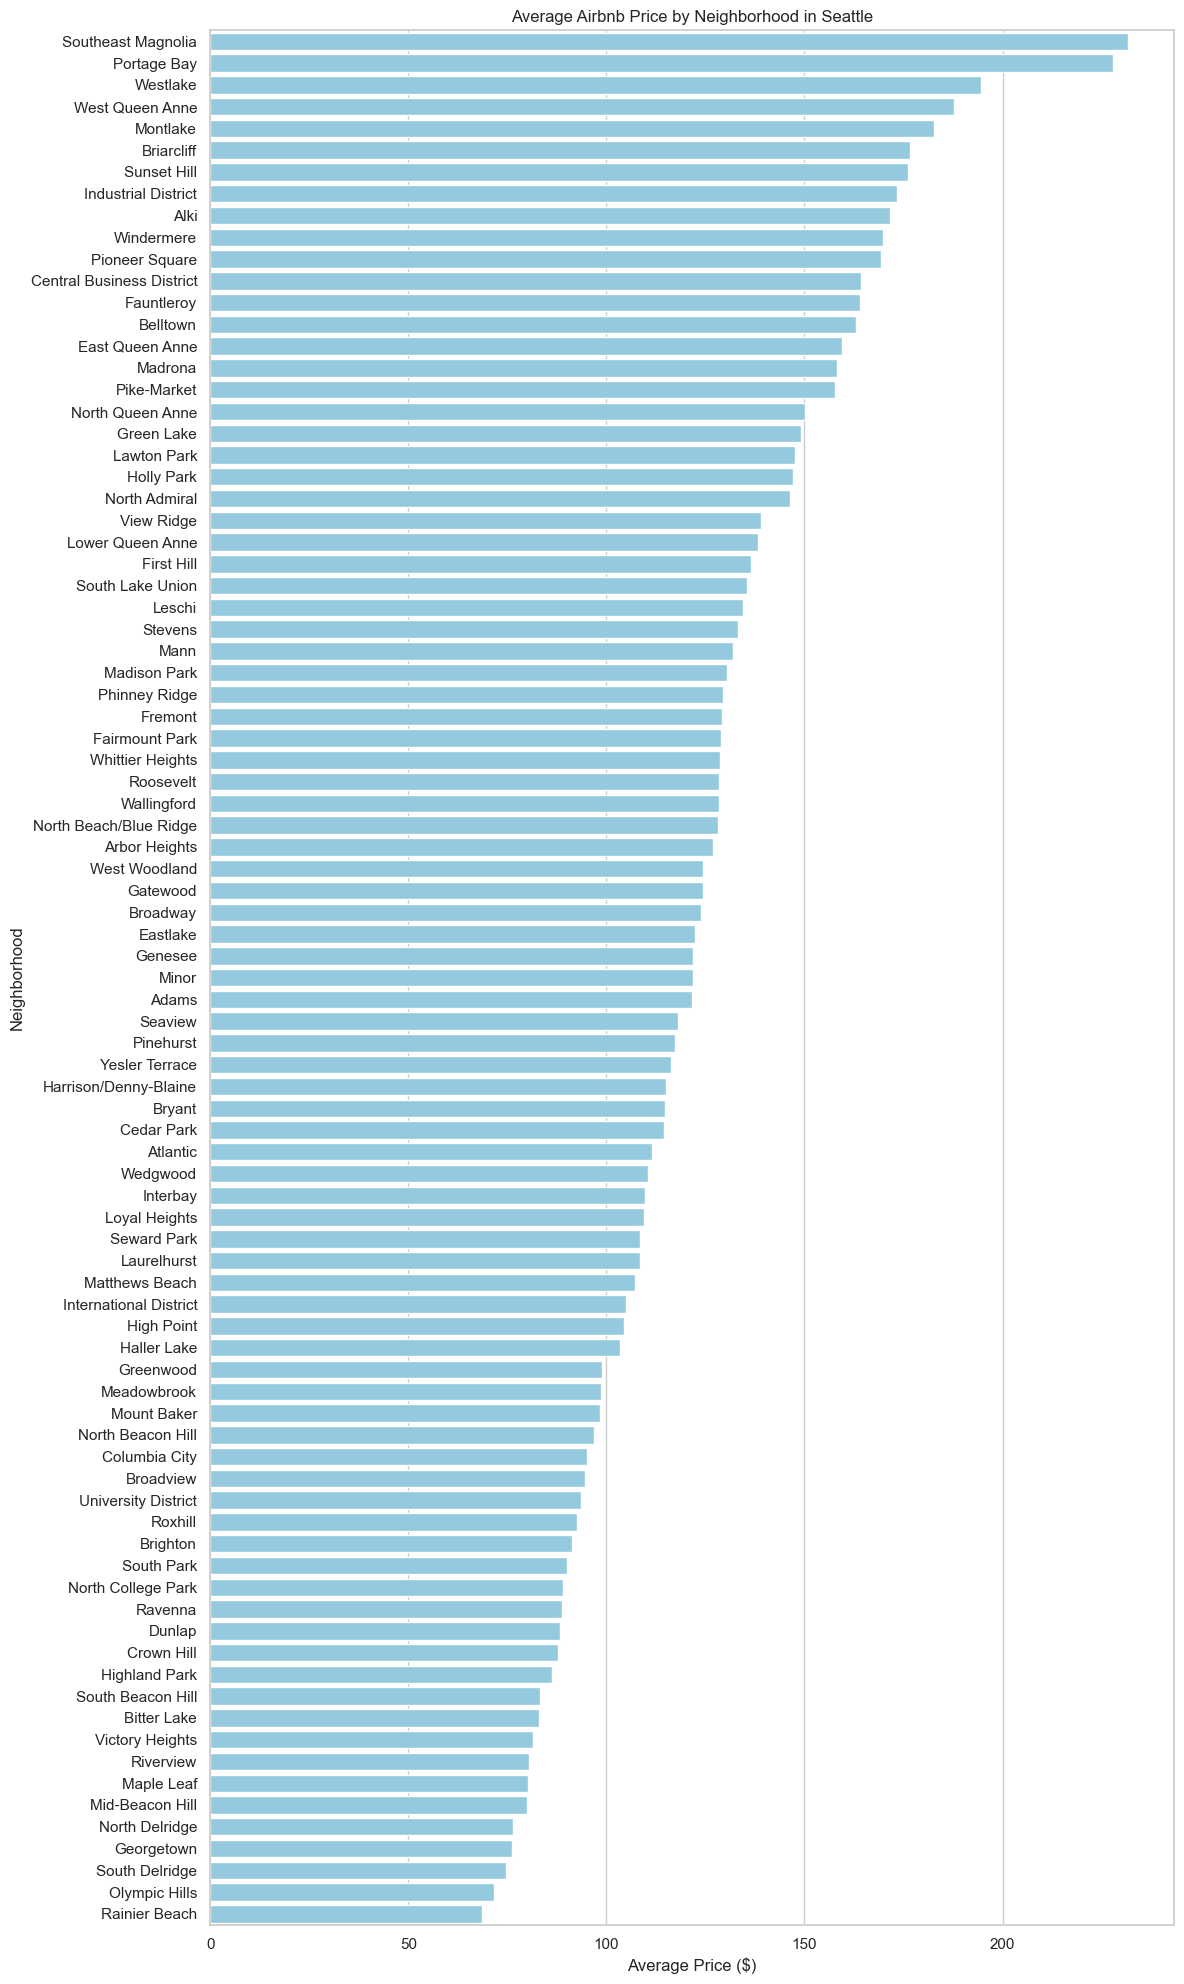

In [9]:
neighborhood_avg_price = df.groupby('neighbourhood_cleansed')['price'].mean().sort_values(ascending=False)

# Plotting
plt.figure(figsize=(12, 20))
sns.barplot(x=neighborhood_avg_price.values, y=neighborhood_avg_price.index, color='skyblue')
plt.title('Average Airbnb Price by Neighborhood in Seattle')
plt.xlabel('Average Price ($)')
plt.ylabel('Neighborhood')
plt.tight_layout()
plt.show()

# Q2: What is the distribution of listing prices?

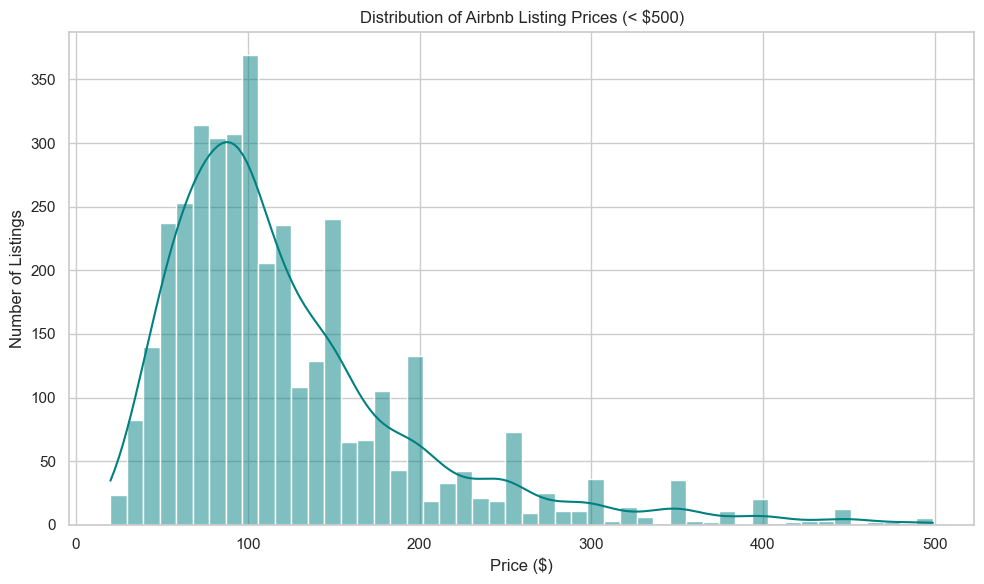

In [10]:

import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

# Filter out very high prices to avoid skewing the distribution
df_filtered = df[df['price'] < 500]  # You can adjust this threshold if needed

# Plot distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_filtered['price'], bins=50, kde=True, color='teal')
plt.title('Distribution of Airbnb Listing Prices (< $500)')
plt.xlabel('Price ($)')
plt.ylabel('Number of Listings')
plt.tight_layout()
plt.show()

# Q3: What is the average price by neighborhood and room type?

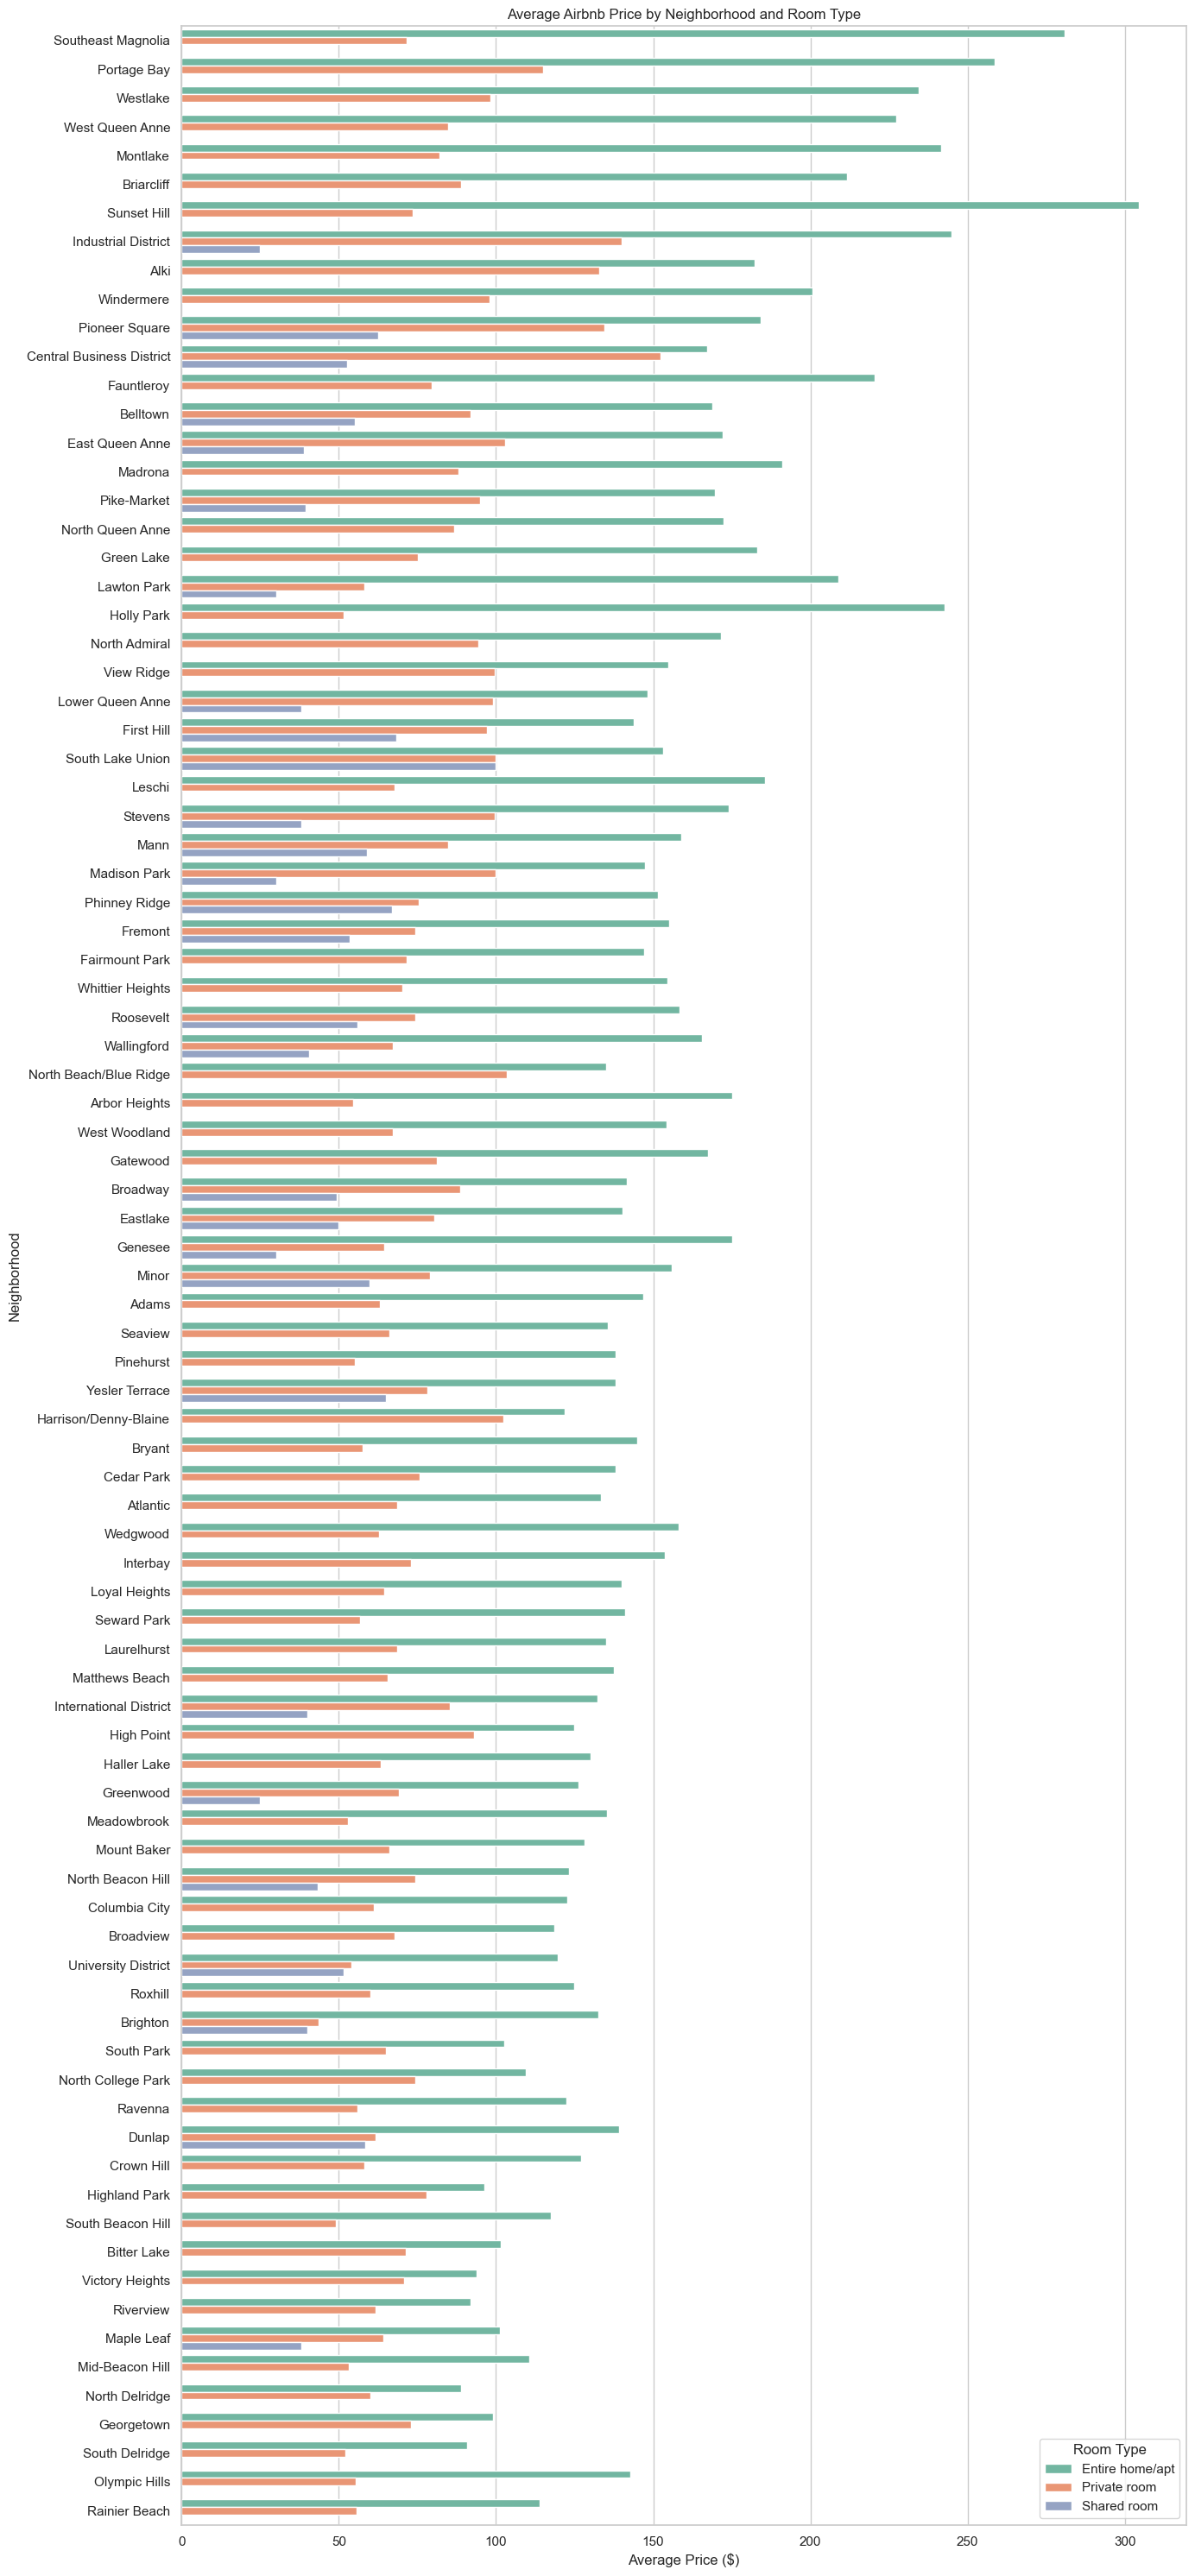

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('listings.csv')

# Clean the 'price' column
df['price'] = df['price'].replace({r'\$': '', ',': ''}, regex=True).astype(float)

# Group data by neighborhood and room type, compute mean price
grouped = df.groupby(['neighbourhood_cleansed', 'room_type'])['price'].mean().reset_index()

# Sort neighborhoods by overall average price to keep plot consistent
neighborhood_order = df.groupby('neighbourhood_cleansed')['price'].mean().sort_values(ascending=False).index

# Plotting
plt.figure(figsize=(14, 30))
sns.barplot(
    data=grouped,
    x='price',
    y='neighbourhood_cleansed',
    hue='room_type',
    order=neighborhood_order,
    palette='Set2'
)

plt.title('Average Airbnb Price by Neighborhood and Room Type')
plt.xlabel('Average Price ($)')
plt.ylabel('Neighborhood')
plt.legend(title='Room Type')
plt.tight_layout()
plt.show()

# Q4: How does host response time affect average price?

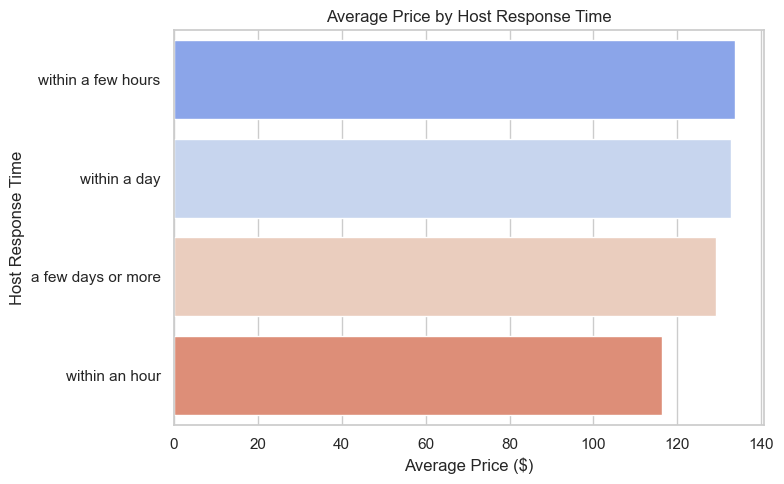

In [13]:
response_price = df.groupby('host_response_time')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=response_price.values,
    y=response_price.index,
    hue=response_price.index,    # Add hue to remove the deprecation warning
    dodge=False,                 # Prevent overlapping
    palette="coolwarm",
    legend=False                 # Disable the legend since hue is used only for coloring
)
plt.title('Average Price by Host Response Time')
plt.xlabel('Average Price ($)')
plt.ylabel('Host Response Time')
plt.tight_layout()
plt.show()

# Q5: What are the most common amenities offered?

(Assuming `amenities_df` is pre-processed already with top 20 amenities)

In [17]:
# Extract amenities from the 'amenities' column
# Remove curly braces and split the string into individual amenities
df['amenities_list'] = df['amenities'].str.replace(r'[{}"]', '', regex=True).str.split(',')

# Flatten the list of amenities across all listings
from collections import Counter
amenity_counter = Counter([amenity.strip() for sublist in df['amenities_list'].dropna() for amenity in sublist])

# Convert the counter to a DataFrame
amenities_df = pd.DataFrame(amenity_counter.items(), columns=['Amenity', 'Count'])

# Sort and select the top 20 amenities
amenities_df = amenities_df.sort_values(by='Count', ascending=False).head(20)

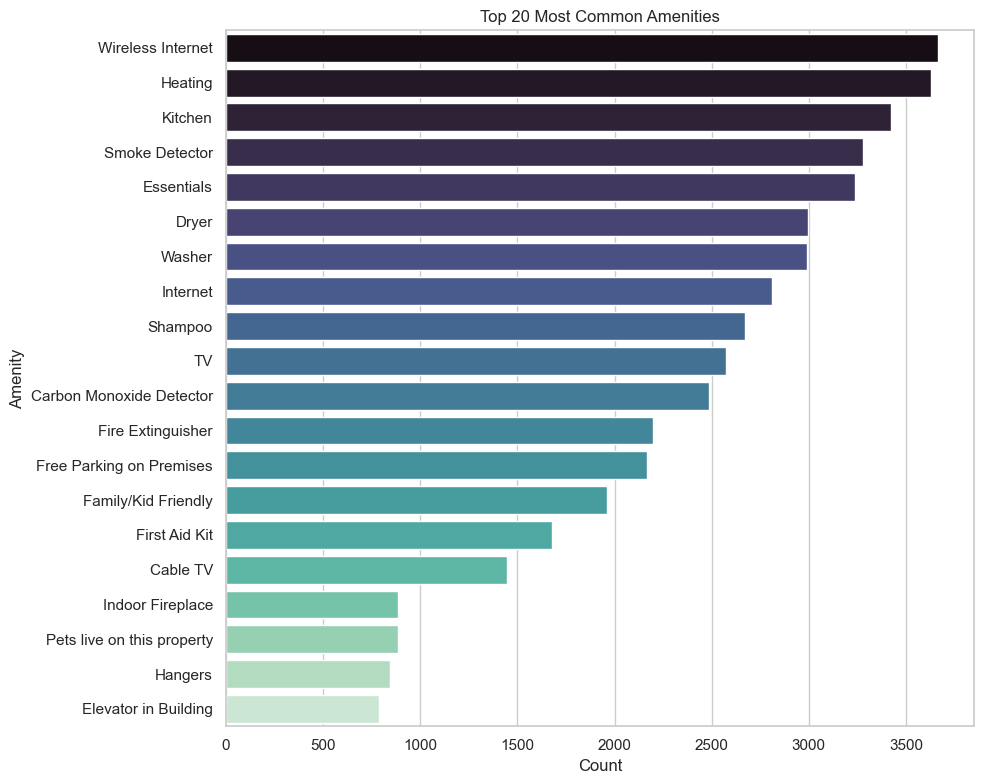

In [18]:
# Updated bar plot for top 20 amenities
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Count',
    y='Amenity',
    data=amenities_df,
    hue='Amenity',           # Assign hue to satisfy future versions
    dodge=False,             # Prevent overlapping
    palette='mako',
    legend=False             # Disable legend since hue is just for coloring
)
plt.title('Top 20 Most Common Amenities')
plt.xlabel('Count')
plt.ylabel('Amenity')
plt.tight_layout()
plt.show()

###  6. Deployment

The insights generated from this notebook can be used to support blog articles, dashboards, or pricing strategy recommendations for Airbnb hosts in Seattle.

Further extension could include predictive modeling to forecast prices or availability based on host features, seasonality, or competition.
